# Pipeline analisi mutazioni — utilizzo di utils.py
Basta cambiare `PATH` e i parametri, poi eseguire le celle in ordine.

##  INIT

In [1]:
from utils import (generate_matrices, calculate_statistics,
                    plot_volcanos, build_all_networks,
                    calculate_metrics, compare_networks, run_cohort_analysis,run_comparison)

import os
import pandas as pd
import numpy as np

## Funzione di stratificazione

In [2]:
import os
import shutil
import pandas as pd

def stratify_cohort(input_dir, output_dir, master_filename, filter_type, **kwargs):
    print(f"\n{'='*50}")
    print(f"=== STRATIFICAZIONE: {os.path.basename(input_dir)} -> {os.path.basename(output_dir)} ===")
    
    master_path = os.path.join(input_dir, master_filename)
    if not os.path.exists(master_path):
        print(f"Errore: File master non trovato -> {master_path}")
        return None, None
        
    group_a_name = "Matched"
    group_b_name = "Unmatched"
        
    master_df = pd.read_csv(master_path, sep='\t', low_memory=False)
    # Standardizzazione ID del file master
    all_ids = set(master_df['Sample_Id'].astype(str).str.strip().unique())
    
    group_a_ids = set()
    
    # --- LOGICA DEI FILTRI ---
    if filter_type == 'mutation':
        gene = kwargs.get('gene')
        if not gene:
            print("Errore: Parametro 'gene' mancante per il filtro mutation.")
            return None, None
            
        mut_files = [f for f in os.listdir(input_dir) if 'mutations' in f.lower()]
        if not mut_files:
             print(f"Errore: Nessun file mutazioni trovato in {input_dir}")
             return None, None
             
        mut_file_path = os.path.join(input_dir, mut_files[0])
        mut_df = pd.read_csv(mut_file_path, sep='\t', low_memory=False)
        
        if 'Hugo_Symbol' not in mut_df.columns or 'Sample_Id' not in mut_df.columns:
            print("Errore: Colonne necessarie ('Hugo_Symbol' o 'Sample_Id') mancanti nel file mutazioni.")
            return None, None
            
        gene_target = str(gene).strip().upper()
        mask = mut_df['Hugo_Symbol'].astype(str).str.strip().str.upper() == gene_target
        
        mutated_samples_raw = mut_df[mask]['Sample_Id'].astype(str).str.strip().unique()
        print(f"[Debug] Trovati {len(mutated_samples_raw)} pazienti con mutazione {gene_target} nel file mutazioni.")
        
        group_a_ids = set(mutated_samples_raw).intersection(all_ids)
        print(f"[Debug] Di questi, {len(group_a_ids)} sono presenti nel master file clinico.")
        
    elif filter_type == 'clinical':
        column = kwargs.get('column')
        value = kwargs.get('value')
        
        if not column or value is None:
            print("Errore: Parametri 'column' o 'value' mancanti per il filtro clinical.")
            return None, None
        
        if column not in master_df.columns:
            print(f"Errore: Colonna clinica '{column}' non trovata nel master.")
            return None, None
            
        mask = master_df[column].astype(str).str.strip() == str(value).strip()
        matched_samples = master_df[mask]['Sample_Id'].astype(str).str.strip().unique()
        group_a_ids = set(matched_samples)
        
    else:
        print("Errore: filter_type deve essere 'mutation' o 'clinical'.")
        return None, None
        
    # --- CALCOLO DEI GRUPPI ---
    group_b_ids = all_ids - group_a_ids
    
    print(f"Totale pazienti nella coorte originale: {len(all_ids)}")
    print(f"  -> Pazienti assegnati a {group_a_name}: {len(group_a_ids)}")
    print(f"  -> Pazienti assegnati a {group_b_name}: {len(group_b_ids)}")
    
    if len(group_a_ids) == 0 or len(group_b_ids) == 0:
        print("! Attenzione: Uno dei due gruppi è vuoto. Controlla i filtri inseriti.")

    # --- CREAZIONE CARTELLE ---
    path_a = os.path.join(output_dir, group_a_name)
    path_b = os.path.join(output_dir, group_b_name)
    os.makedirs(path_a, exist_ok=True)
    os.makedirs(path_b, exist_ok=True)

    # --- SMISTAMENTO DI TUTTI I FILE ---
    print("\nSmistamento dei file in corso...")
    
    for filename in os.listdir(input_dir):
        file_path = os.path.join(input_dir, filename)
        
        if not os.path.isfile(file_path):
            continue
            
        # Ottimizzazione: Leggiamo solo le prime righe per capire la struttura senza caricare gigabyte inutilmente
        preview_df = pd.read_csv(file_path, sep='\t', nrows=5)
        
        # CASO 1: Struttura per Righe (es. Clinici, Mutazioni)
        if 'Sample_Id' in preview_df.columns:
            df = pd.read_csv(file_path, sep='\t', low_memory=False)
            df['Sample_Id_clean'] = df['Sample_Id'].astype(str).str.strip()
            
            df_a = df[df['Sample_Id_clean'].isin(group_a_ids)].drop(columns=['Sample_Id_clean'])
            df_b = df[df['Sample_Id_clean'].isin(group_b_ids)].drop(columns=['Sample_Id_clean'])
            
            df_a.to_csv(os.path.join(path_a, filename), sep='\t', index=False)
            df_b.to_csv(os.path.join(path_b, filename), sep='\t', index=False)
            print(f"[Righe]   {filename}: {len(df_a)} righe in {group_a_name} | {len(df_b)} righe in {group_b_name}")
            
        else:
            # Pulisco i nomi delle colonne della preview per il controllo
            clean_preview_cols = [str(c).strip() for c in preview_df.columns]
            col_ids = set(clean_preview_cols).intersection(all_ids)
            
            # CASO 2: Struttura per Colonne (es. Matrici di Espressione, CNA)
            if len(col_ids) > 0:
                df = pd.read_csv(file_path, sep='\t', low_memory=False)
                # Normalizziamo momentaneamente i nomi delle colonne per evitare mismatch da spazi bianchi
                orig_cols = df.columns.tolist()
                df.columns = [str(c).strip() for c in df.columns]
                
                # Identifichiamo le colonne clinico/genomiche fisse (es. Hugo_Symbol, Entrez_Gene_Id)
                base_cols = [c for c in df.columns if c not in all_ids]
                
                cols_a = base_cols + [c for c in df.columns if c in group_a_ids]
                cols_b = base_cols + [c for c in df.columns if c in group_b_ids]
                
                df_a = df[cols_a]
                df_b = df[cols_b]
                
                # Ripristiniamo i nomi colonne originali prima del salvataggio
                # (creando una mappa inversa solo per le colonne rimaste)
                rename_map = {str(orig): orig for orig in orig_cols}
                df_a = df_a.rename(columns=rename_map)
                df_b = df_b.rename(columns=rename_map)
                
                df_a.to_csv(os.path.join(path_a, filename), sep='\t', index=False)
                df_b.to_csv(os.path.join(path_b, filename), sep='\t', index=False)
                print(f"[Colonne] {filename}: {len(cols_a)-len(base_cols)} campioni in {group_a_name} | {len(cols_b)-len(base_cols)} campioni in {group_b_name}")
            
            # CASO 3: File di annotazione o metadati generali (Copiare intatti)
            else:
                shutil.copy2(file_path, os.path.join(path_a, filename))
                shutil.copy2(file_path, os.path.join(path_b, filename))
                print(f"[Copiato] {filename}: File condiviso copiato intatto in entrambi i gruppi.")

    print(f"=== FATTO ===")
    return path_a, path_b

## Prova con TP53

In [3]:
COOCC_PARAMS = {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3}
ME_PARAMS    = {"p_val": 0.01, "log2or": -1.0}

['Current Age', 'Sample coverage', 'Stage (Highest Recorded)', 'Age_Num', 'Age_Group']
Aggiornamento file clinico master: KRAS_F_colon.csv...
  -> Colonna 'Age_Group' creata/aggiornata.
  -> Colonna 'TMB_Group' creata/aggiornata.
  -> Colonna 'FGA_Group' creata/aggiornata.
Salvataggio completato con successo.


=== STRATIFICAZIONE: kras_colon -> kras_Age_Group_colon ===
Totale pazienti nella coorte originale: 609
  -> Pazienti assegnati a Matched: 239
  -> Pazienti assegnati a Unmatched: 370

Smistamento dei file in corso...
[Righe]   F_data_mutations.txt: 2819 righe in Matched | 3741 righe in Unmatched
[Righe]   KRAS_F_colon.csv: 239 righe in Matched | 370 righe in Unmatched
[Righe]   F_data_SV.csv: 28 righe in Matched | 35 righe in Unmatched
[Colonne] F_data_cna.txt: 239 campioni in Matched | 370 campioni in Unmatched
=== FATTO ===

AVVIO PIPELINE: MATCHED

🧬 PREPARAZIONE DATI MUTAZIONI (SNV): MATCHED

📊 --- STATISTICHE RETE FINALE (SNV) ---
  • Dimensioni: 239 Campioni x 404 Geni un

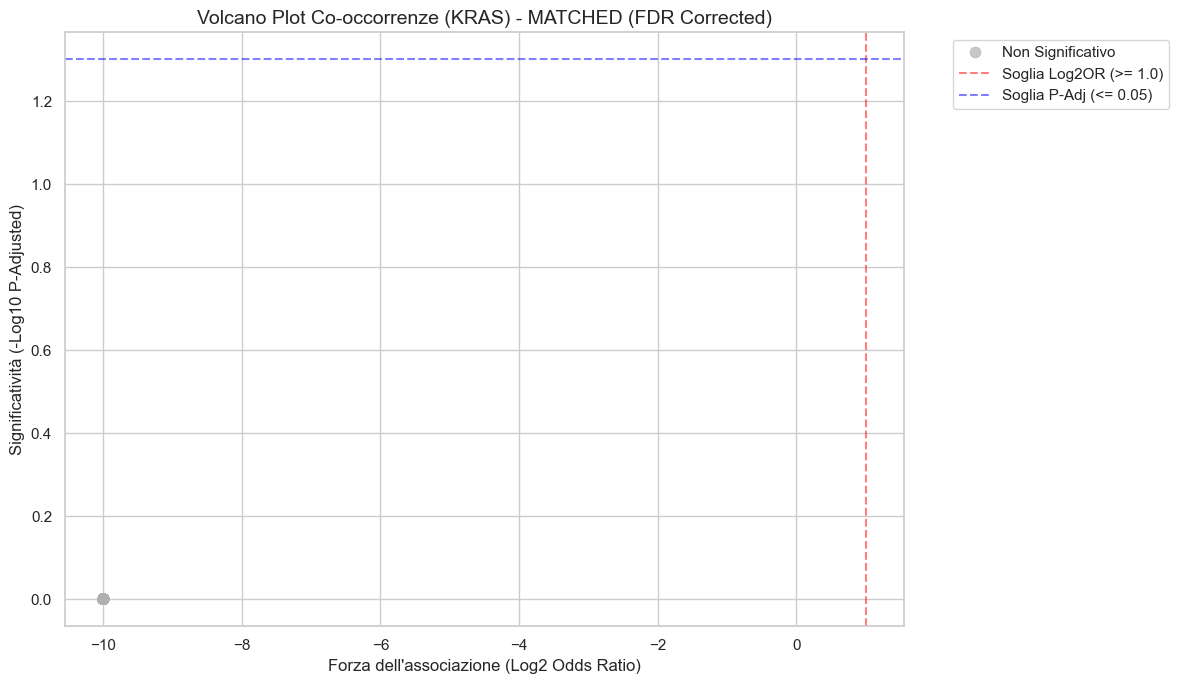

✅ Volcano Plot Co-occorrenze (P-Adj) salvato e visualizzato.



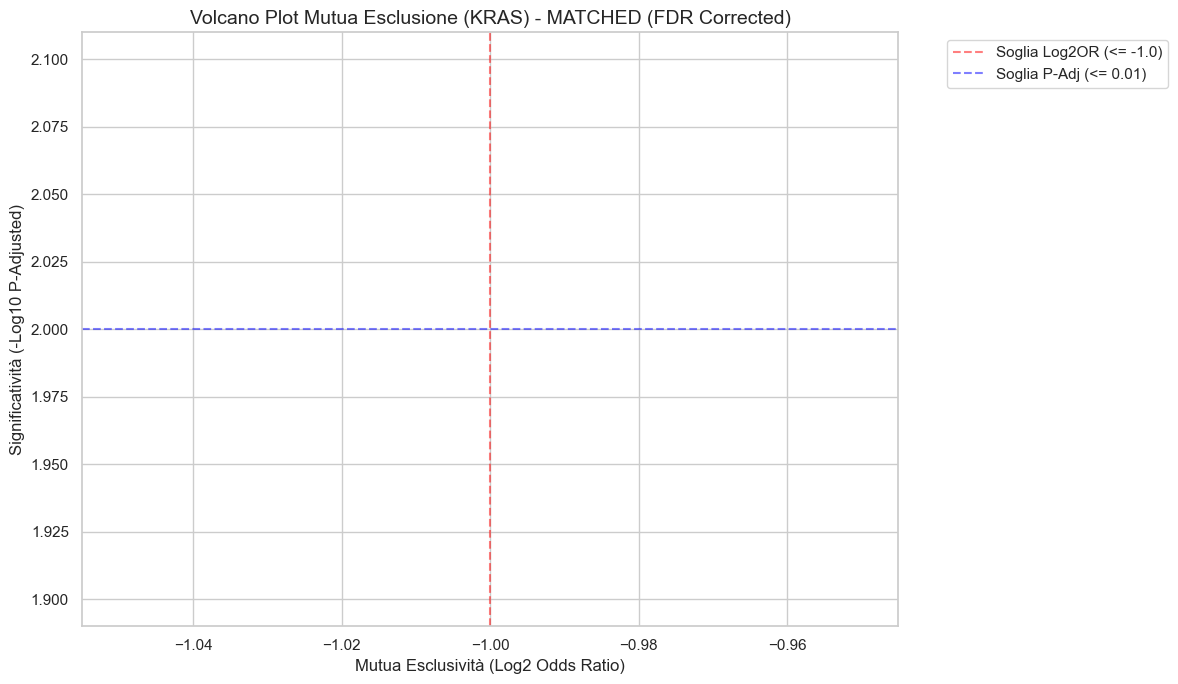

✅ Volcano Plot Mutua Esclusione (P-Adj) salvato e visualizzato.


--- 🌐 GENERAZIONE RETI 2D: MATCHED ---

📊 LEIDEN METRICS -> K: 6 | Modularity: 0.2840 | Silhouette: 0.0436
📁 File cluster salvato in: ./strat/kras_Age_Group_colon/Matched/networks/Cluster_Genes_FULL_Matched.tsv


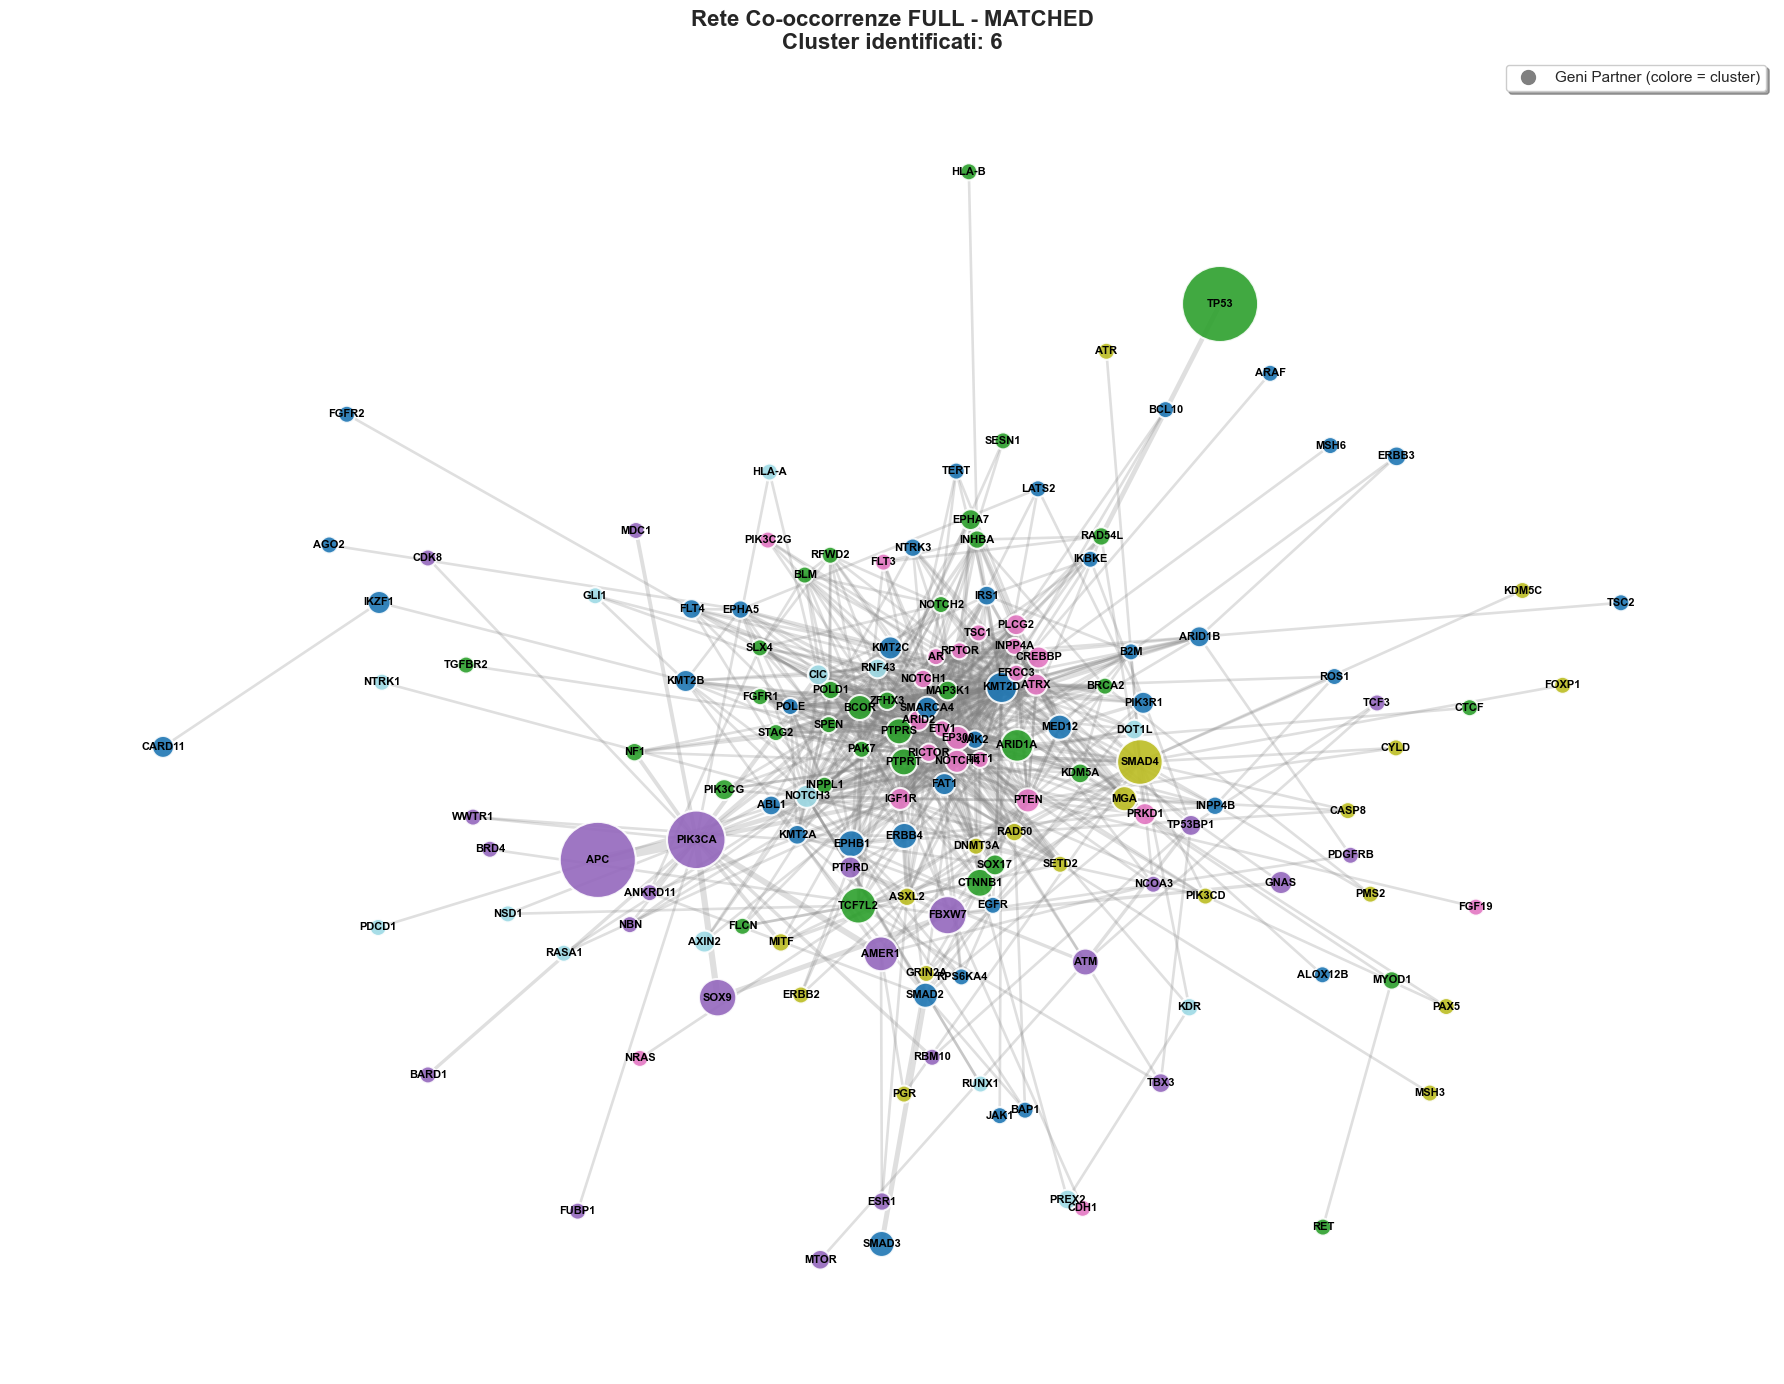

✅ Rete FULL per MATCHED salvata. Nodi: 154, Archi: 873
[!] KRAS non presente nella rete (non supera i filtri).

--- 📊 ESTRAZIONE METRICHE: MATCHED ---
[-] KRAS non presente, calcolo metriche annullato.

🎯 RICERCA HUB INTRACLUSTER: MATCHED (FULL)
✅ Report Top Hubs salvato in: ./strat/kras_Age_Group_colon/Matched/intracluster/Report_Prof_TopHubs_FULL_Matched.txt

🌟 ENRICHMENT DEGLI HUB: MATCHED (FULL)
✅ Analisi completata! Risultati salvati in: ./strat/kras_Age_Group_colon/Matched/intracluster/enrichment/Enrichment_NetworkHubs_FULL_Matched.tsv

--- ⏳ SURVIVAL ANALYSIS: MATCHED ---


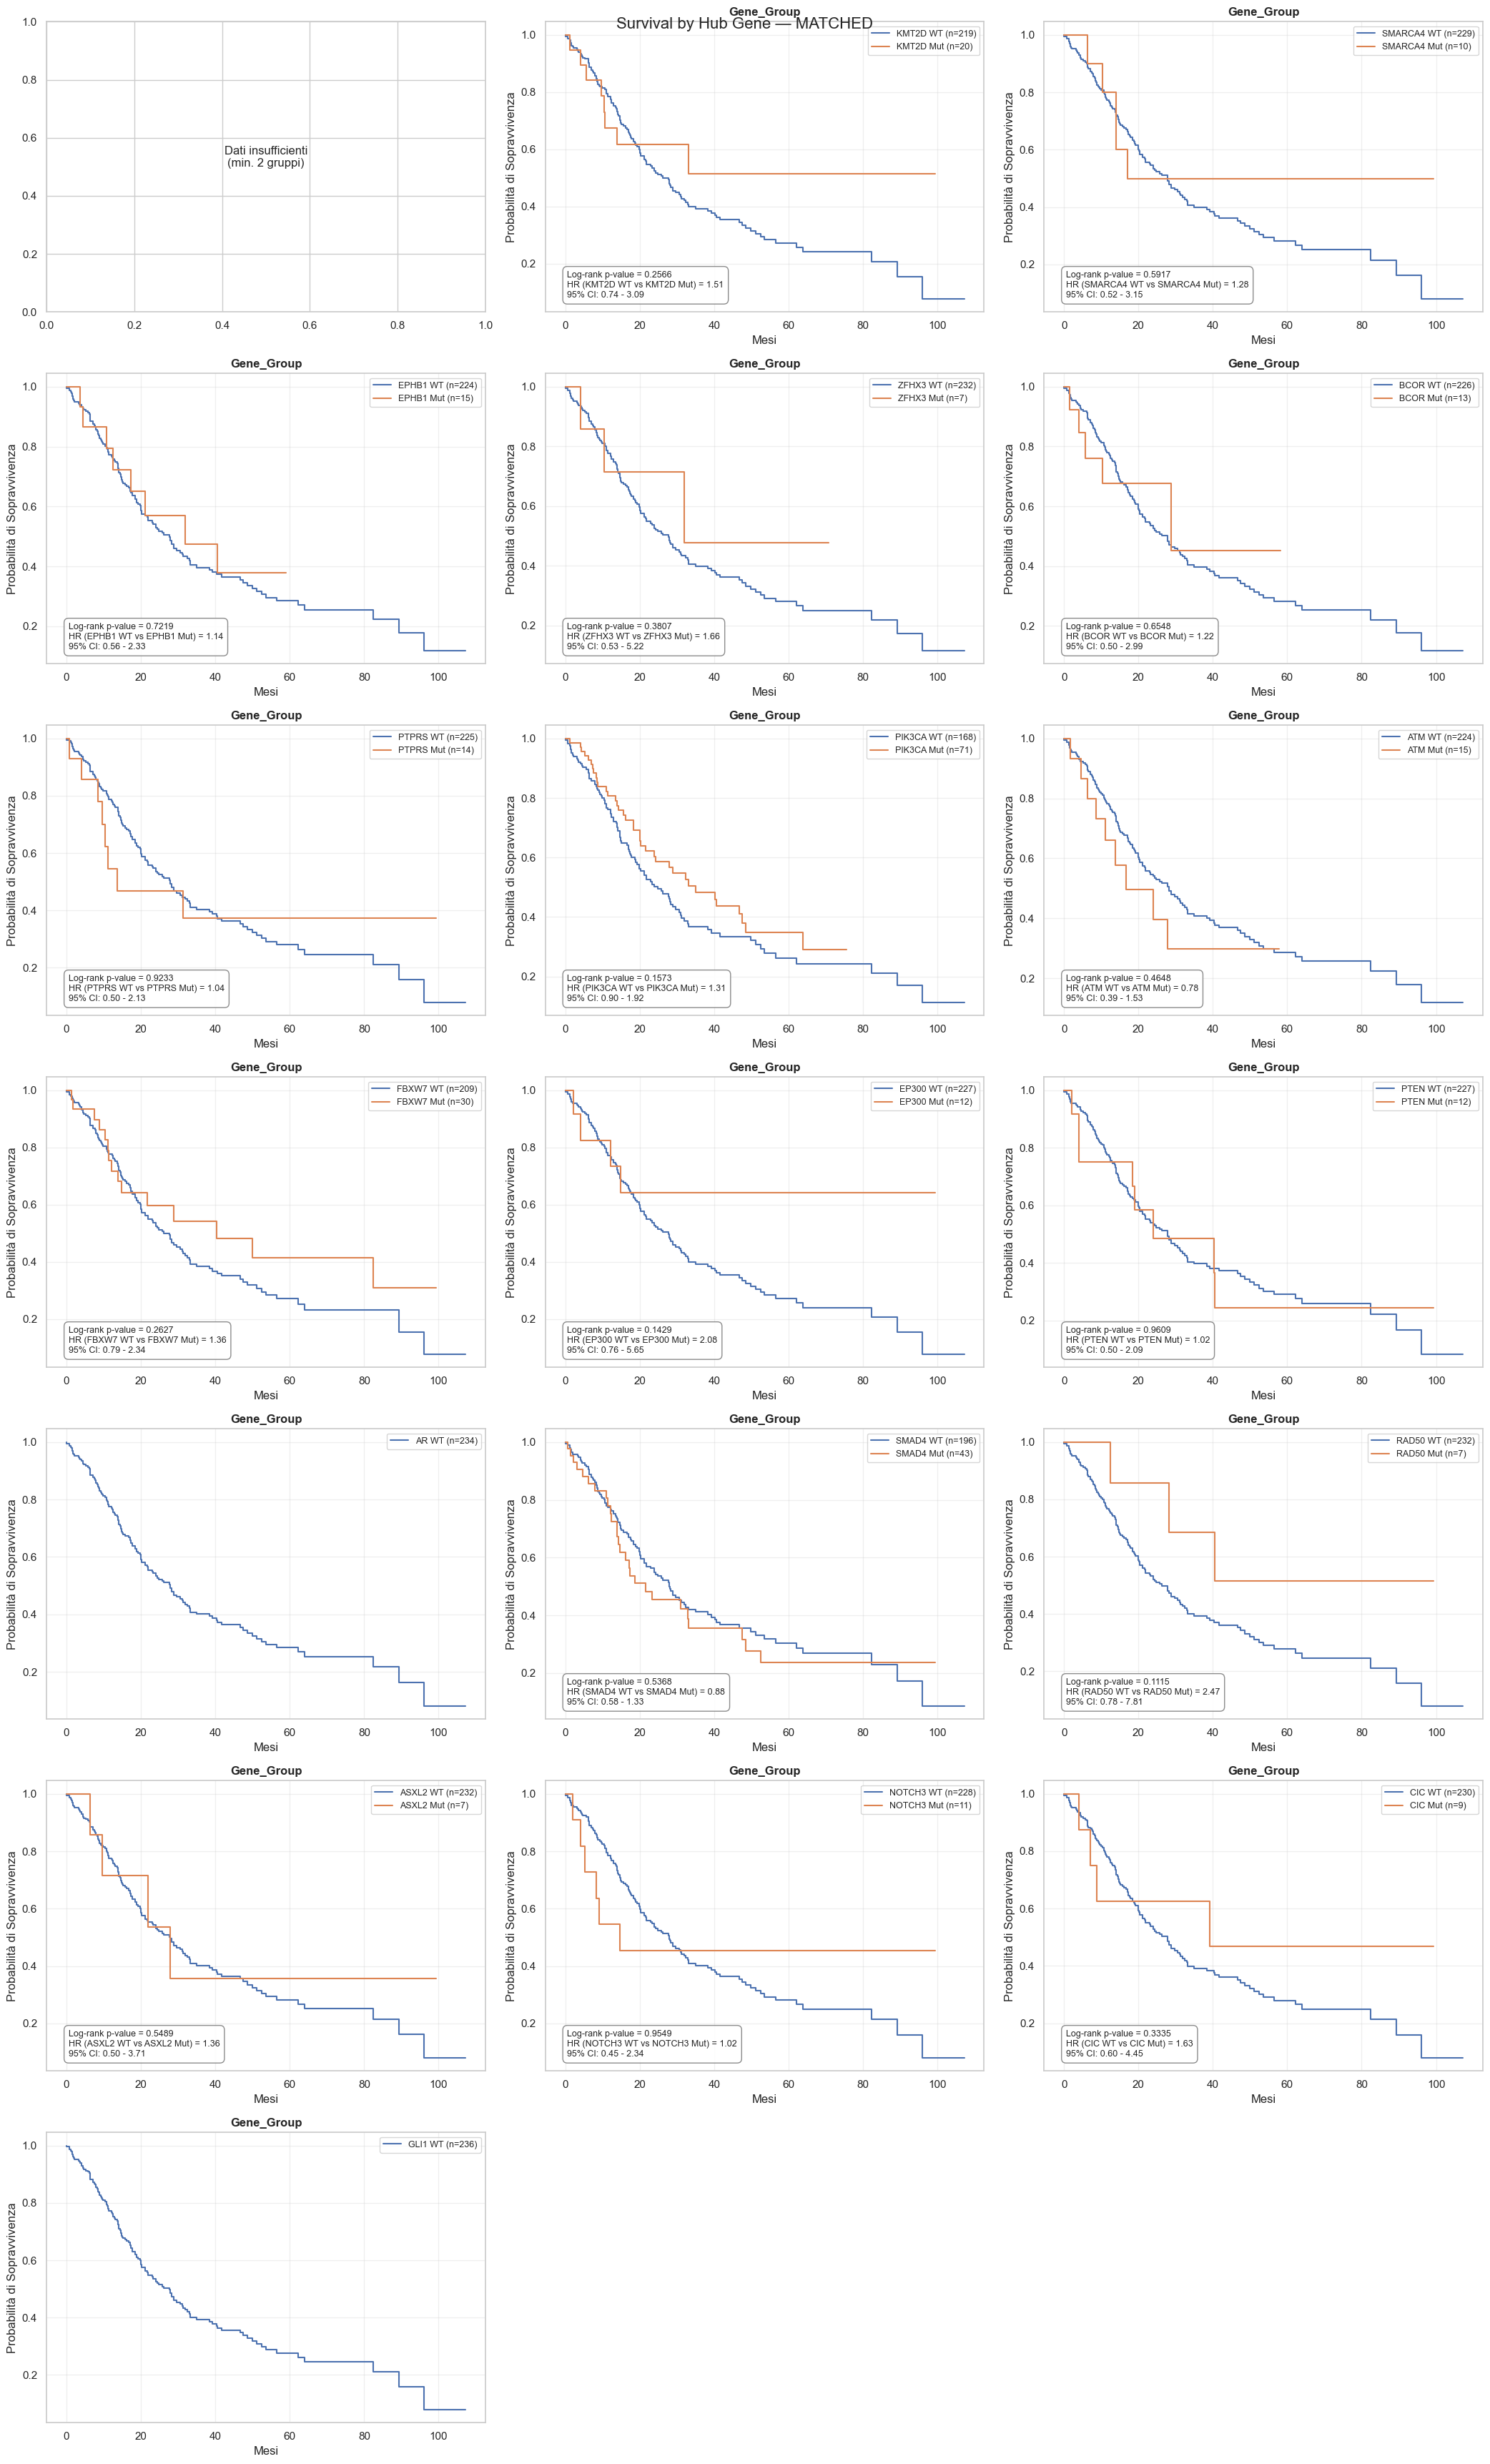

✅ Plot sopravvivenza salvato in: ./strat/kras_Age_Group_colon/Matched/plots/Survival_Hubs_Matched.png

AVVIO PIPELINE: UNMATCHED

🧬 PREPARAZIONE DATI MUTAZIONI (SNV): UNMATCHED

📊 --- STATISTICHE RETE FINALE (SNV) ---
  • Dimensioni: 370 Campioni x 412 Geni unici
  • Densità matrice: 2.11%

  🔥 Top 5 Geni Driver (SNV):
    - KRAS: 370 pazienti (100.0%)
    - APC: 302 pazienti (81.6%)
    - TP53: 263 pazienti (71.1%)
    - PIK3CA: 88 pazienti (23.8%)
    - SMAD4: 75 pazienti (20.3%)

✅ Matrici SNV salvate in: ./strat/kras_Age_Group_colon/Unmatched/matrices

--- 🧮 CALCOLO STATISTICHE: UNMATCHED ---
[*] Calcolo Co-occorrenza globale...
✅ Statistiche di Co-occorrenza salvate.
[*] Calcolo Mutua Esclusività per KRAS...
✅ Statistiche di Mutua Esclusività salvate.

--- 🌋 GENERAZIONE PLOTS (P-Adj): UNMATCHED ---


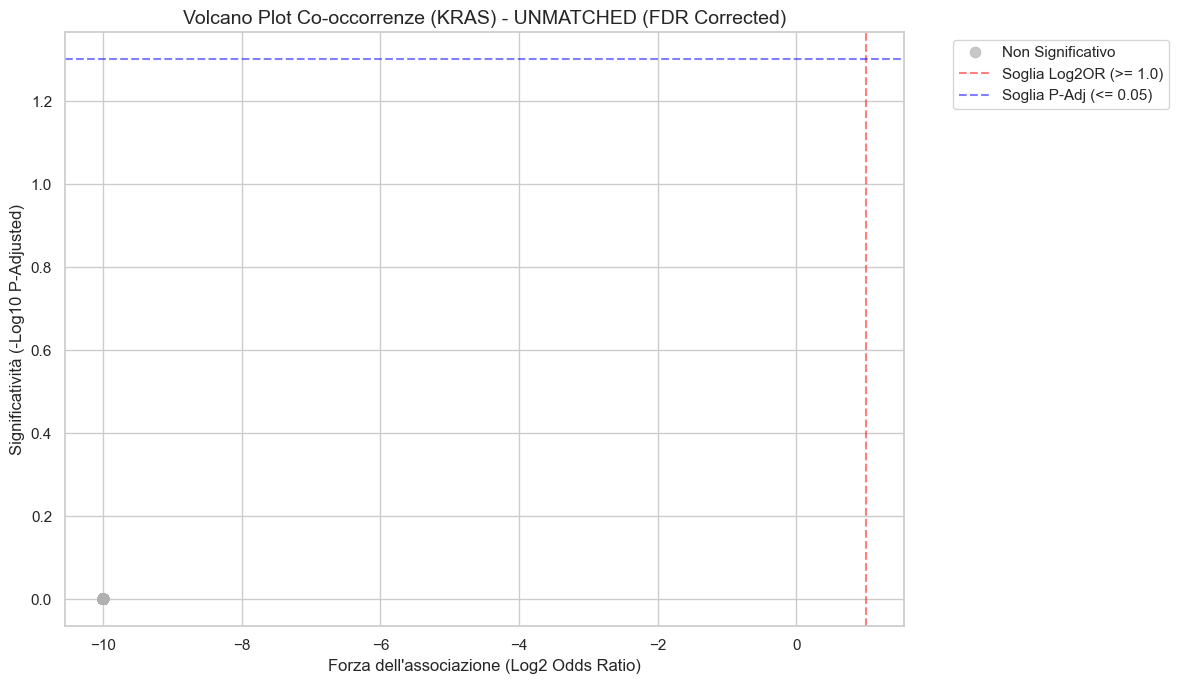

✅ Volcano Plot Co-occorrenze (P-Adj) salvato e visualizzato.



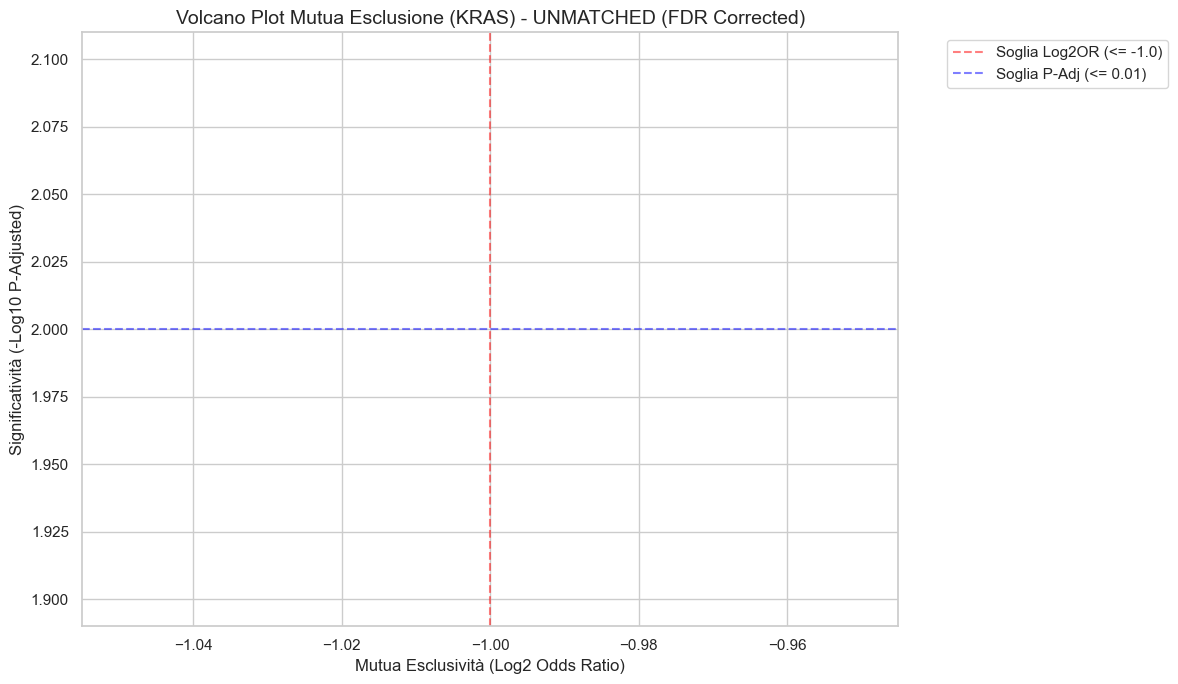

✅ Volcano Plot Mutua Esclusione (P-Adj) salvato e visualizzato.


--- 🌐 GENERAZIONE RETI 2D: UNMATCHED ---

📊 LEIDEN METRICS -> K: 7 | Modularity: 0.2249 | Silhouette: 0.0762
📁 File cluster salvato in: ./strat/kras_Age_Group_colon/Unmatched/networks/Cluster_Genes_FULL_Unmatched.tsv


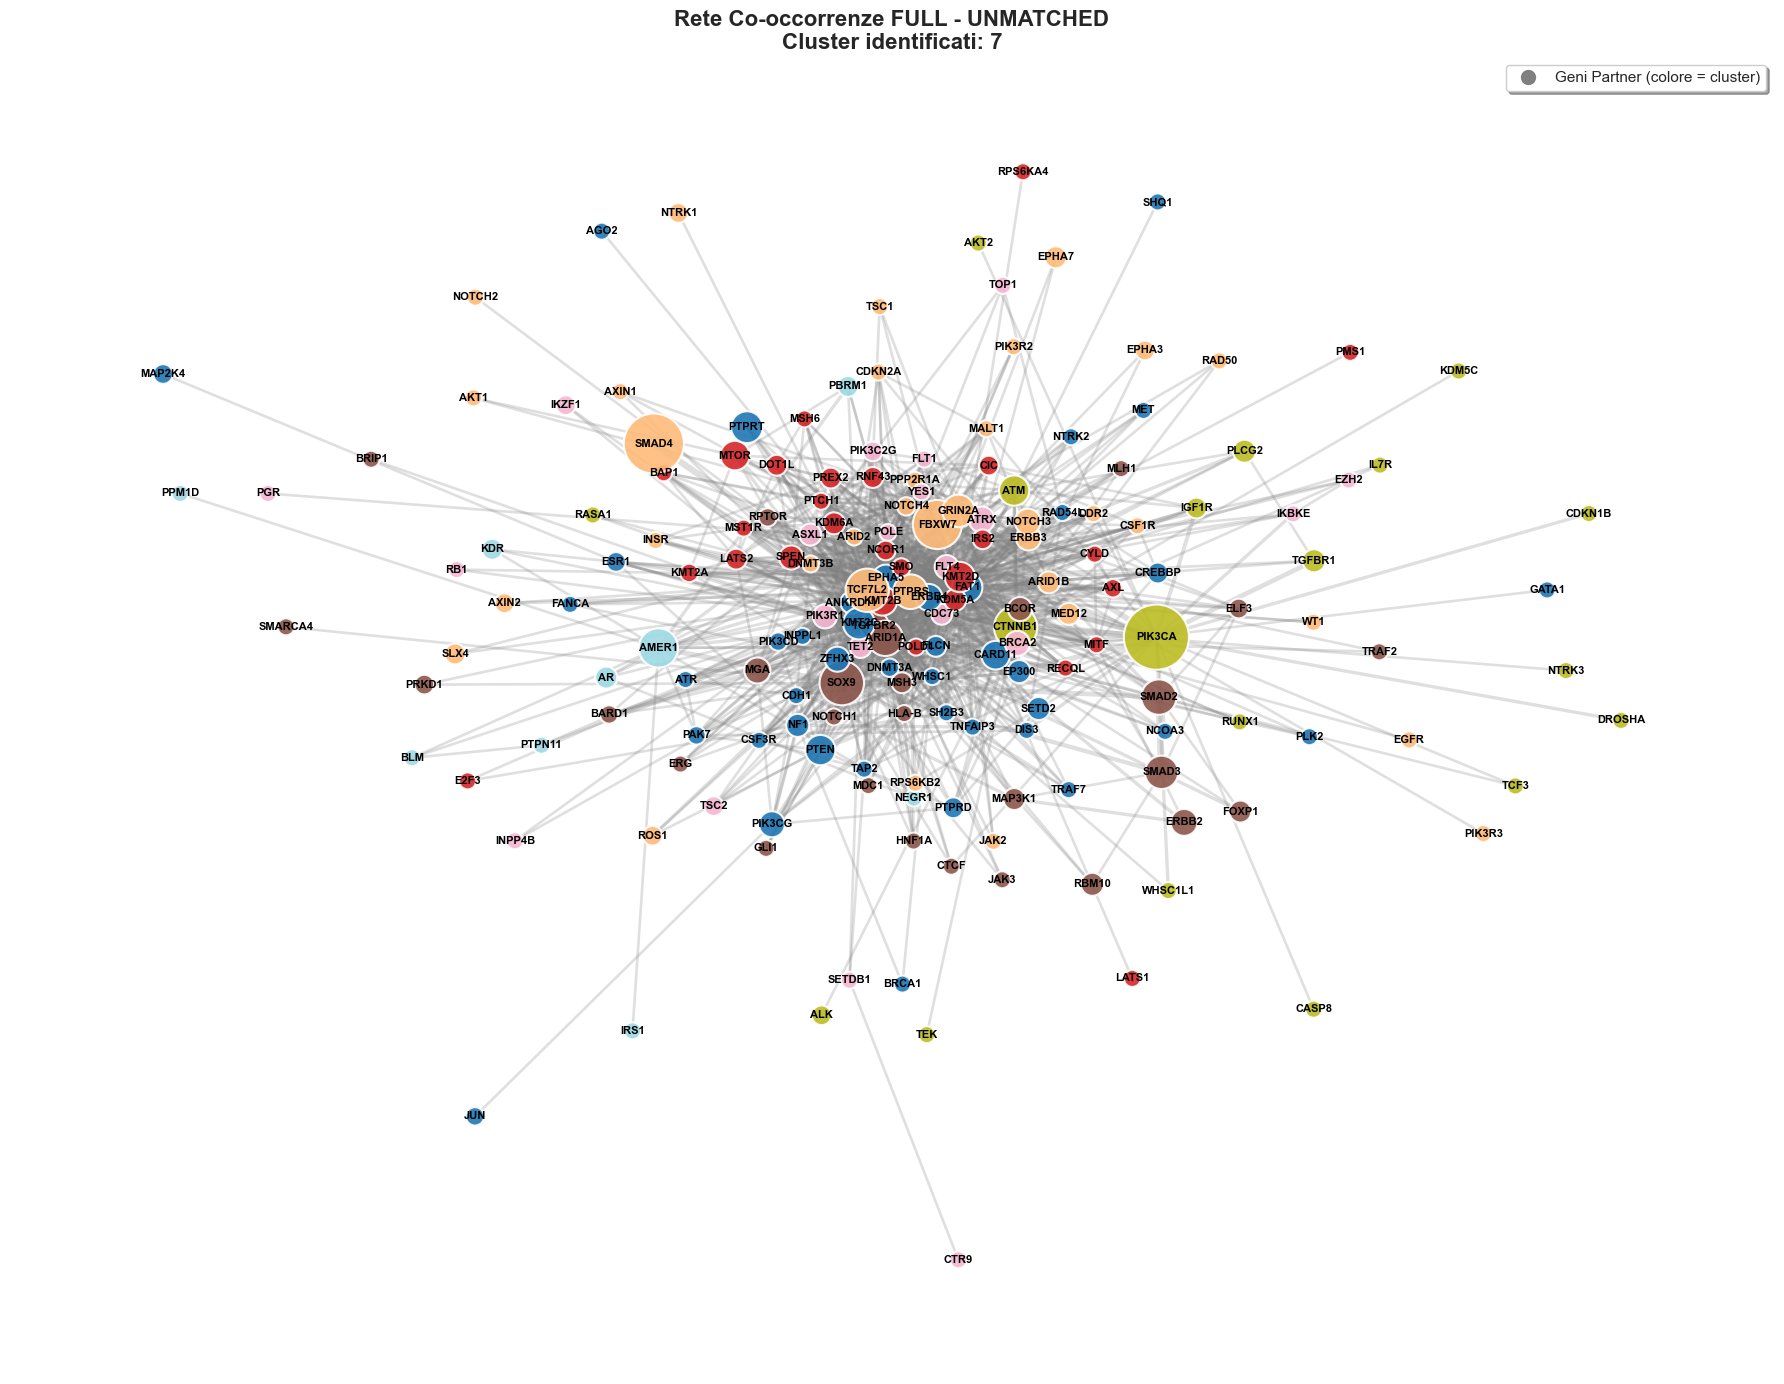

✅ Rete FULL per UNMATCHED salvata. Nodi: 182, Archi: 1322
[!] KRAS non presente nella rete (non supera i filtri).

--- 📊 ESTRAZIONE METRICHE: UNMATCHED ---
[-] KRAS non presente, calcolo metriche annullato.

🎯 RICERCA HUB INTRACLUSTER: UNMATCHED (FULL)
✅ Report Top Hubs salvato in: ./strat/kras_Age_Group_colon/Unmatched/intracluster/Report_Prof_TopHubs_FULL_Unmatched.txt

🌟 ENRICHMENT DEGLI HUB: UNMATCHED (FULL)
✅ Analisi completata! Risultati salvati in: ./strat/kras_Age_Group_colon/Unmatched/intracluster/enrichment/Enrichment_NetworkHubs_FULL_Unmatched.tsv

--- ⏳ SURVIVAL ANALYSIS: UNMATCHED ---


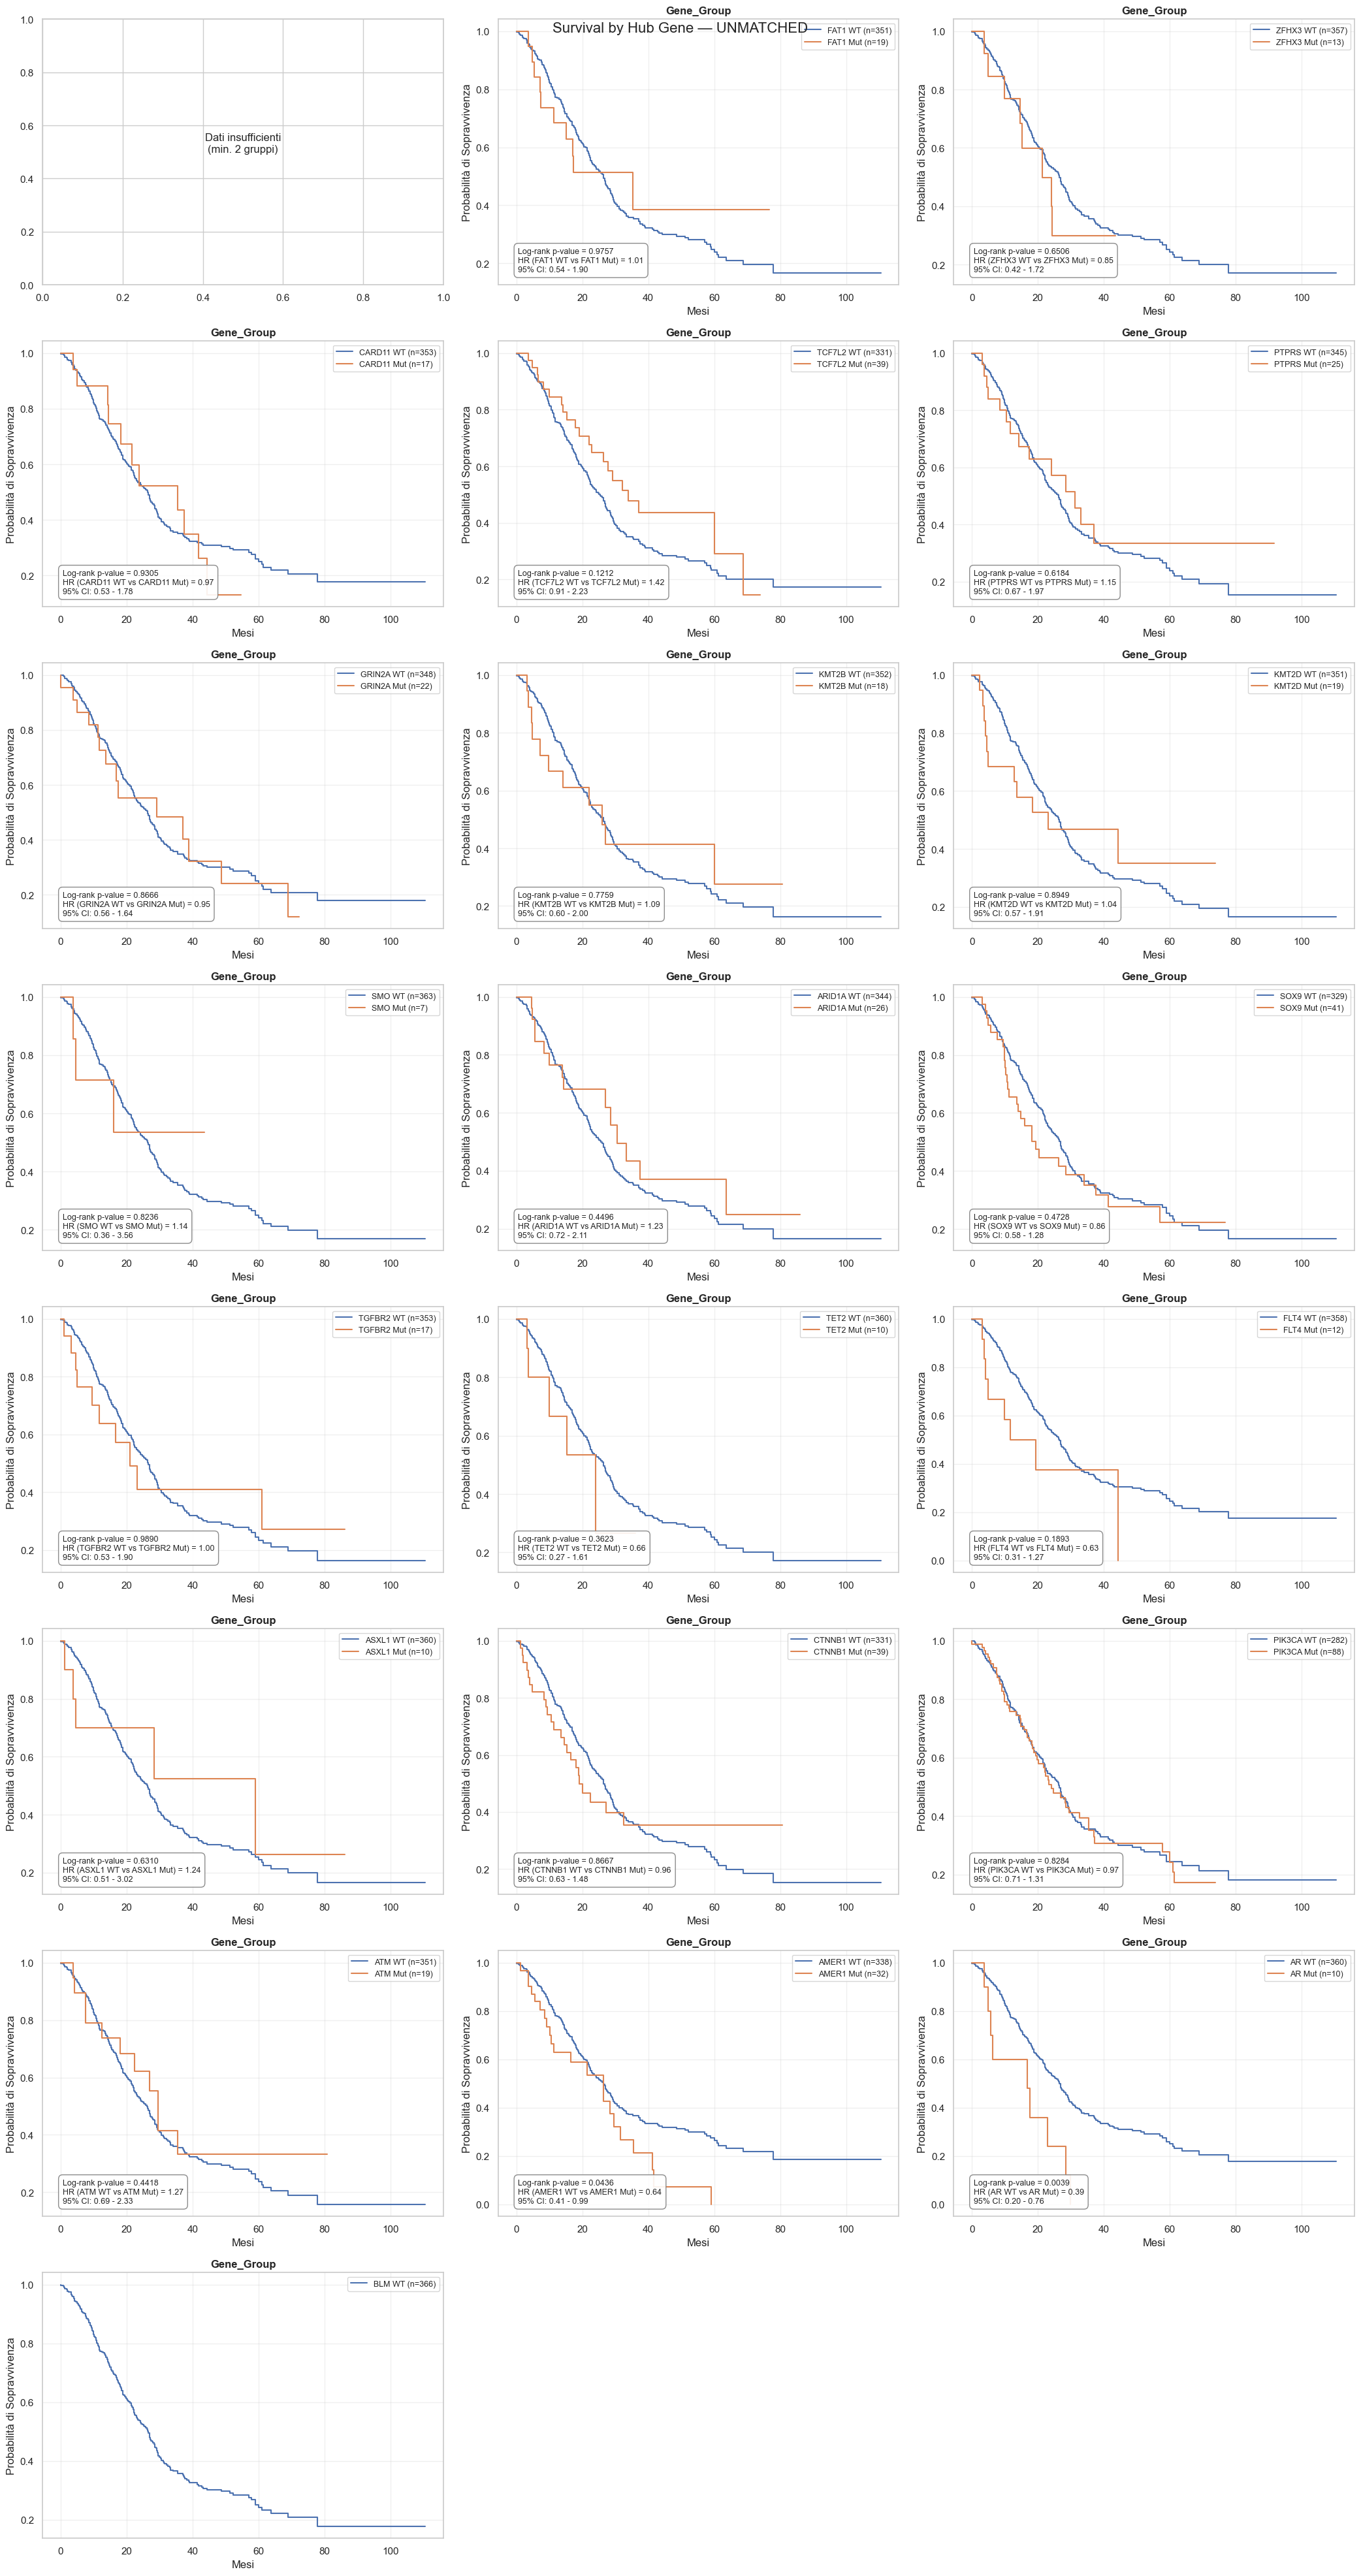

✅ Plot sopravvivenza salvato in: ./strat/kras_Age_Group_colon/Unmatched/plots/Survival_Hubs_Unmatched.png

CONFRONTO: MATCHED vs UNMATCHED

--- 📈 KAPLAN-MEIER COMPARATIVO ---


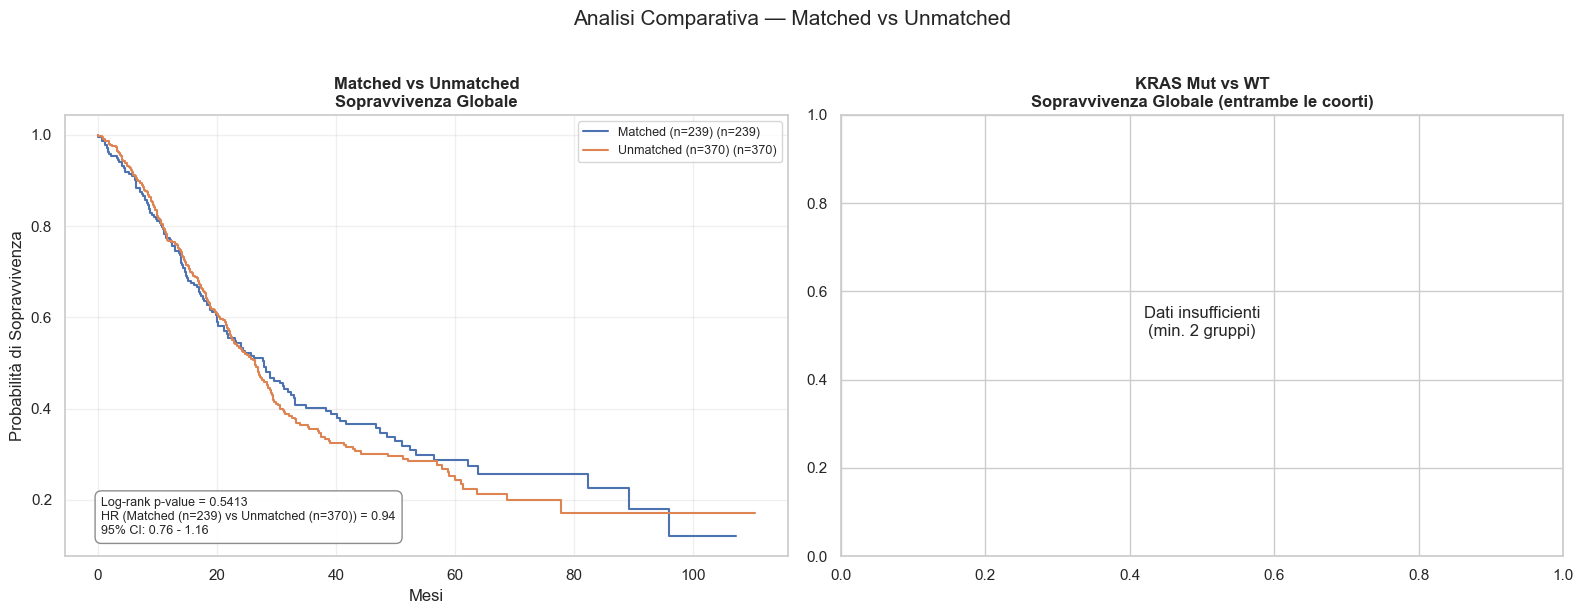

✅ Plot KM comparativo salvato in: ./strat/kras_Age_Group_colon/KM_Comparison_KRAS.png

--- 🔍 FEATURE SIGNIFICATIVE: MATCHED ---
❌ Nessuna delle feature testate ha mostrato differenze significative.

--- 🔍 FEATURE SIGNIFICATIVE: UNMATCHED ---
❌ Nessuna delle feature testate ha mostrato differenze significative.

--- 🔀 CONFRONTO RETI ---

--- 🔀 CONFRONTO RETI: MATCHED vs UNMATCHED ---
Archi totali in MATCHED: 873
Archi totali in UNMATCHED: 1322
Archi in comune: 129
Archi persi (presenti solo in MATCHED): 744
Archi guadagnati (presenti solo in UNMATCHED): 1193

Top 5 archi guadagnati (per Log2OR):
Gene_A Gene_B    Log2OR    P_Adj
 SH2B3   TAP2 10.096715 0.000647
  EZH2  KMT2D 10.000000 0.002245
 ASXL1   TOP1 10.000000 0.001182
 EP300   PLK2 10.000000 0.001403
CDKN2A  PTPRS 10.000000 0.002908


 Elaborazione di tutti i gruppi conclusa con successo!


In [ ]:
import os
import pandas as pd
import numpy as np

#Vuoi stratificare perFEATURE da usareFEATURE_VALUEEtàAge_Group>= 65 Years / < 65 YearsFGAFGA_GroupHigh FGA / Low FGATMBTMB_GroupHigh TMB / Low TMBTipo campioneSample TypePrimary / Metastasis

# --- CONFIGURAZIONE ---
TARGET_GENE   = "KRAS"
FEATURE       = "Age_Group"  # Colonna clinica da utilizzare per la stratificazione
FEATURE_PATH  = FEATURE.replace(" ", "_")
FEATURE_VALUE = ">= 65 Years"    # oppure "< 65 Years"

INPUT_PATH  = "./data_filtered/kras_colon"
OUTPUT_PATH = "./strat/kras_" + FEATURE_PATH + "_colon"
FILE        = 'KRAS_F_colon.csv'

COOCC_PARAMS = {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3}
ME_PARAMS    = {"p_val": 0.01, "log2or": -1.0}

master_path = os.path.join(INPUT_PATH, FILE)

df = pd.read_csv(os.path.join(INPUT_PATH, FILE), sep='\t', nrows=2)
print([c for c in df.columns if 'age' in c.lower()])

# --- PHASE 1 ---
if os.path.exists(master_path):
    print(f"Aggiornamento file clinico master: {FILE}...")
    df_clinical = pd.read_csv(master_path, sep='\t', low_memory=False)

    # Gestisce sia 'Current Age' che 'Current_Age'
    age_col = next((c for c in df_clinical.columns if c.lower().replace('_', ' ') == 'current age'), None)
    if age_col:
        df_clinical['Age_Num'] = pd.to_numeric(df_clinical[age_col], errors='coerce')
        df_clinical['Age_Group'] = np.where(df_clinical['Age_Num'] >= 65, '>= 65 Years', '< 65 Years')
        df_clinical.loc[df_clinical['Age_Num'].isna(), 'Age_Group'] = np.nan
        print("  -> Colonna 'Age_Group' creata/aggiornata.")

    if 'TMB (nonsynonymous)' in df_clinical.columns:
        df_clinical['TMB_Num'] = pd.to_numeric(df_clinical['TMB (nonsynonymous)'], errors='coerce')
        df_clinical['TMB_Group'] = pd.qcut(df_clinical['TMB_Num'], q=2, labels=['Low TMB', 'High TMB'])
        print("  -> Colonna 'TMB_Group' creata/aggiornata.")

    if 'Fraction Genome Altered' in df_clinical.columns:
        df_clinical['FGA_Num'] = pd.to_numeric(df_clinical['Fraction Genome Altered'], errors='coerce')
        df_clinical['FGA_Group'] = pd.qcut(df_clinical['FGA_Num'], q=2, labels=['Low FGA', 'High FGA'])
        print("  -> Colonna 'FGA_Group' creata/aggiornata.")

    df_clinical.to_csv(master_path, sep='\t', index=False)
    print("Salvataggio completato con successo.\n")
else:
    print(f"Errore critico: Impossibile trovare il file master in {master_path}")

# --- PHASE 2 ---
path_matched, path_unmatched = stratify_cohort(
    input_dir       = INPUT_PATH,
    output_dir      = OUTPUT_PATH,
    master_filename = FILE,
    filter_type     = 'clinical',
    column          = FEATURE,        # "Age_Group"
    value           = FEATURE_VALUE   # ">= 65 Years"
)

# --- PHASE 3 ---
if path_matched and path_unmatched:
    for PATH in [path_matched, path_unmatched]:
        run_cohort_analysis(PATH, TARGET_GENE, COOCC_PARAMS, ME_PARAMS, clinical_file=FILE)
    run_comparison(path_matched, path_unmatched, TARGET_GENE, FILE, COOCC_PARAMS)
    print("\n Elaborazione di tutti i gruppi conclusa con successo!")
else:
    print("\n Interruzione della pipeline: errore nella generazione dei gruppi.")